<a href="https://colab.research.google.com/github/LuGorr/NLP-Assignments/blob/main/A1/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Group members

|  Name   |  Surname   |     Email                            |    Student ID                                             |
| :-----: | :--------: | :----------------------------------: | :-----------------------------------------------------: |
| Ludovico  | Gorrieri   | `ludovico.gorrieri@studio.unibo.it`   |  0001199160 |
| Alessandro  | Capialbi | `alessandro.capialbi@studio.unibo.it`  | 0001191564 |
| Faezeh  | Sarlakifar | `faezeh.sarlakifar@studio.unibo.it`  | 0001164608 |

## Project setup.

### Clone the repository and install the required dependencies.

In [ ]:
# @title
!git clone https://github.com/nlp-unibo/nlp-course-material.git
%cd "nlp-course-material/2025-2026/Assignment 1"
!pip install -qq gensim
print("\ngensim installed!")
!pip install -qq plotly
print("plotly installed!")
!pip install -qq nltk
print("nltk installed!")
!pip install -qq transformers
print("transformers installed!")
!pip install -qq datasets
print("datasets installed!")
!pip install -qq accelerate -U
print("accelerate installed!")
!pip install -qq evaluate
print("evaluate installed!")
!pip install -qq bitsandbytes
print("bitsandbytes installed!")
!pip install -qq wandb
print("wandb installed!")

fatal: destination path 'nlp-course-material' already exists and is not an empty directory.
/content/nlp-course-material/2025-2026/Assignment 1

gensim installed!
plotly installed!
nltk installed!
transformers installed!
datasets installed!
accelerate installed!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
evaluate installed!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 16.3 MB/s eta 0:00:00
bitsandbytes installed!
wandb installed!


### Import the reqired libraries.

In [ ]:
# @title
# --- Standard Library & Utilities ---
import os
import sys
import re
import json
import gc
import random
from random import shuffle
from collections import Counter
from itertools import product

# --- Data Science & Numerics ---
import numpy as np
import pandas as pd

# --- NLP (NLTK & Gensim) ---
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.tokenize import (word_tokenize,
                            sent_tokenize,
                            WhitespaceTokenizer)
import gensim
import gensim.downloader as gloader
from gensim.models import KeyedVectors

# --- Plotting & Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# --- Scikit-Learn & Tracking ---
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, accuracy_score)
import wandb

# --- TensorFlow & Keras ---
import tensorflow as tf
import keras
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, Callback
from tensorflow.keras import backend as K
from tqdm.keras import TqdmCallback
tf_data = tf.data
os.environ["KERAS_BACKEND"] = "tensorflow"

# --- PyTorch & HuggingFace ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import Dataset
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)

## Task 1 & 2

### NTLK and function definitions.

In [ ]:
# Prepare NLTK Resources.
resources = [
    ('corpora/omw-1.4', 'omw-1.4'),
    ('corpora/wordnet', 'wordnet'),
    ('taggers/averaged_perceptron_tagger', 'averaged_perceptron_tagger'),
    ('taggers/averaged_perceptron_tagger_eng', 'averaged_perceptron_tagger_eng'),
    ('tokenizers/punkt_tab', 'punkt_tab'),
    ('tokenizers/punkt', 'punkt')
]

for resource_path, download_name in resources:
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(download_name, quiet=True)

# Initialize the tokenizer and lemmatizer.
tokenizer = WhitespaceTokenizer()
lemmatizer = WordNetLemmatizer()


def get_wordnet_key(pos_tag):
    """
    Maps Penn Treebank POS tags to WordNet's format
    (Required by WordNetLemmatizer).
    """
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return 'n'


def lem_text(row):
    """
    Tokenizes and lemmatizes a row's tweet.
    """
    tokens = tokenizer.tokenize(row.tweet) # Tokenize.
    tagged = pos_tag(tokens) # Tag the tokens.

    # Convert the tagged tokens to WordNet and lemmatize them.
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag))
             for word, tag in tagged]
    return " ".join(words)

def cleaner(row):
    """
    Cleans a row's tweet.
    """
    text = row.tweet
    text = text.lower() # Transform to lowercase.
    text = re.sub(r'https?:\/\/.\S+', '', text) # Remove URLs.
    text = re.sub(r'[@#].\S+', '', text) # Remove hashtags and mentions.

    text = re.sub( # Remove unwanted symbols.
        "["
            u"\U0001F600-\U0001F64F"  # Emoticons.
            u"\U0001F300-\U0001F5FF"  # Symbols & pictographs.
            u"\U0001F680-\U0001F6FF"  # Transport & map symbols.
            u"\U0001F1E0-\U0001F1FF"  # Flags.
                                    "]+", '', text
    )

    # Only keep numbers and latin alphabet letters.
    text = re.sub(r'[^a-z^0-9^\s]*', '', text)

    text = ' '.join(text.split())
    return text


def plot_dists(train, test, extra_title=""):
    """
    Plots train and test set distributions.
    - Class distribution (in percentage points over the set).
    - Tweet length distribution.
    - Per class tweet length distribution.
    """
    # Class distribution histogram.
    pio.renderers.default = "colab"
    label_map = {0: "NOT SEXIST", 1: "DIRECT", 2: "JUDGEMENTAL", 3: "REPORTED"}
    category_order = ["NOT SEXIST", "DIRECT", "JUDGEMENTAL", "REPORTED"]
    train_plot = train.copy()
    test_plot = test.copy()
    train_plot["dataset"] = "Training Set"
    test_plot["dataset"] = "Test Set"
    df_all = pd.concat([train_plot, test_plot])
    df_all["label_name"] = df_all["label"].map(label_map)
    df_counts = df_all.groupby(['dataset', 'label_name']).size().reset_index(name='counts')
    df_counts['percent'] = df_counts.groupby('dataset')['counts'].transform(lambda x: (x / x.sum()) * 100)
    fig = px.bar(
        df_counts,
        x="label_name",
        y="percent",
        color="label_name",
        facet_col_spacing=0.05,
        facet_col="dataset",
        category_orders={"label_name": category_order, "dataset": ["Training Set", "Test Set"]},
        color_discrete_sequence=px.colors.sequential.Plasma,
        text=df_counts['percent'].apply(lambda x: f'{x:.1f}%'), # Etichette precise
        labels={"label_name": "Class", "percent": "Percentage (%)"}
    )
    fig.update_layout(
        width=1000, height=500,
        showlegend=False,
        bargap=0.2,
        title_text="Class Distribution: Percentage of each Set " + extra_title,
        title_x=0.5
    )
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
    fig.update_traces(textposition='outside') # Mette i numeri sopra le barre
    fig.update_yaxes(title_text="Percentage (%)", ticksuffix="%")
    fig.show()

    # Tweet length distribution histogram + kernel density estimator.
    train_plot["text_length"] = train_plot["text"].apply(lambda x: len(x.split()))
    plt.figure(figsize=(10,5))
    sns.histplot(train_plot["text_length"], bins=30, kde=True, color="purple")
    plt.title("Distribution of Tweet Lengths (Training Set)")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

    # Per class tweet length distribution boxplot.
    plt.figure(figsize=(8,5))
    sns.boxplot(x="label", y="text_length",hue="label", legend=False, data=train_plot, palette="viridis")
    plt.title("Tweet Length by Class")
    plt.xlabel("Class")
    plt.ylabel("Tweet Length (words)")
    plt.xticks([0,1,2,3], ['-', 'DIRECT', 'JUDGEMENTAL', 'REPORTED'])
    plt.show()

# Aggregates the labels (labels_task2).
aggregator = lambda row: \
    mapping[Counter([vote for vote in row.labels_task2 if vote != "UNKNOWN"]).most_common(1)[0][0]]

mapping = {
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}

### Clean, split and lemmatize the dataset.

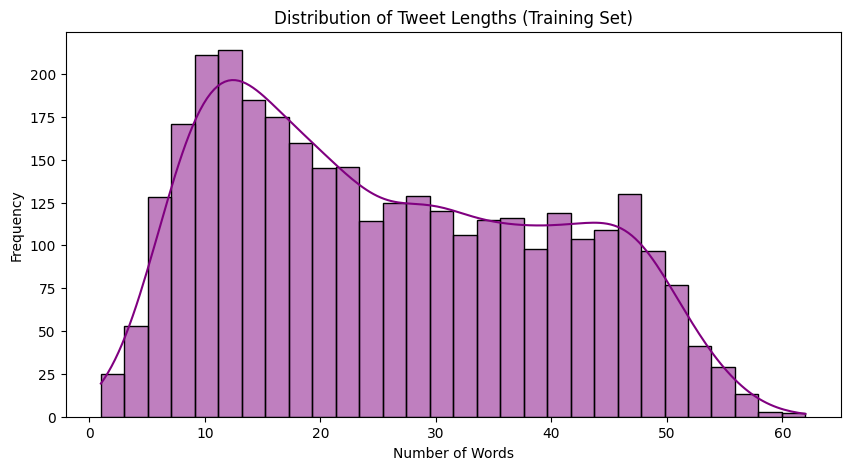

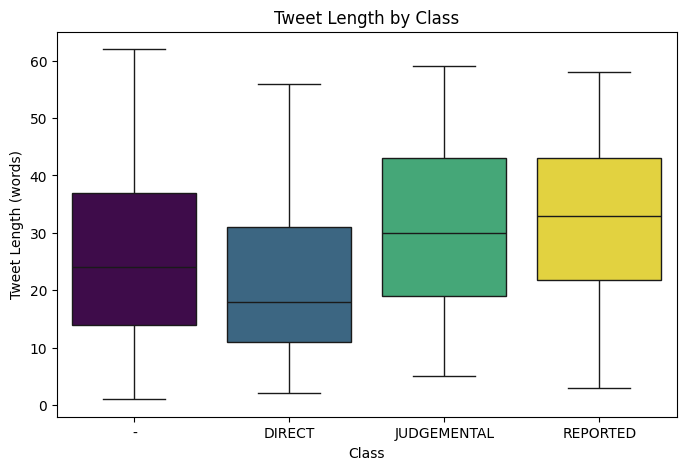

In [ ]:
# Load the JSON files.
with open("data/training.json", "r") as tr, \
     open("data/validation.json", "r") as te, \
     open("data/test.json", "r") as va:
    train_json = json.load(tr)
    val_json = json.load(te)
    test_json = json.load(va)

# Create the dataframes (setting the index to id_EXIST).
dts = {
    "train": pd.DataFrame.from_dict(train_json, orient="index").set_index("id_EXIST"),
    "test": pd.DataFrame.from_dict(test_json, orient="index").set_index("id_EXIST"),
    "val": pd.DataFrame.from_dict(val_json, orient="index").set_index("id_EXIST")
}

# Unnecessary columns
drop_cols = ["number_annotators", "annotators", "gender_annotators",
    "age_annotators", "labels_task1", "labels_task3", "split", "lang"]

# Clean and lemmatize the data
for name, df in dts.items():
    df = df[df.lang == "en"].copy() # Drop spanish.

    df = df.drop(columns=drop_cols) # Drop unnecessary cols.

    df["labels"] = df.apply(aggregator, axis=1) # Aggregate the labels (maj. voting).
    df = df.drop(columns="labels_task2") # Drop the old label column.

    for func in [cleaner, lem_text]:
        df["tweet"] = df.apply(func, axis=1) # Clean the tweets.

    dts[name] = df

# Get the clean train, test and validation datasets
train, test, val = dts.values()

# Rename the columns
train.rename(columns={"labels": "label"}, inplace=True)
train.rename(columns={"tweet": "text"}, inplace=True)
val.rename(columns={"labels": "label"}, inplace=True)
val.rename(columns={"tweet": "text"}, inplace=True)
test.rename(columns={"labels": "label"}, inplace=True)
test.rename(columns={"tweet": "text"}, inplace=True)

# Plot the dataset distributions.
plot_dists(train, test, "(Before Augmentation)")

### Dataset augmentation by random upsampling.

AUGMENTATION DONE!


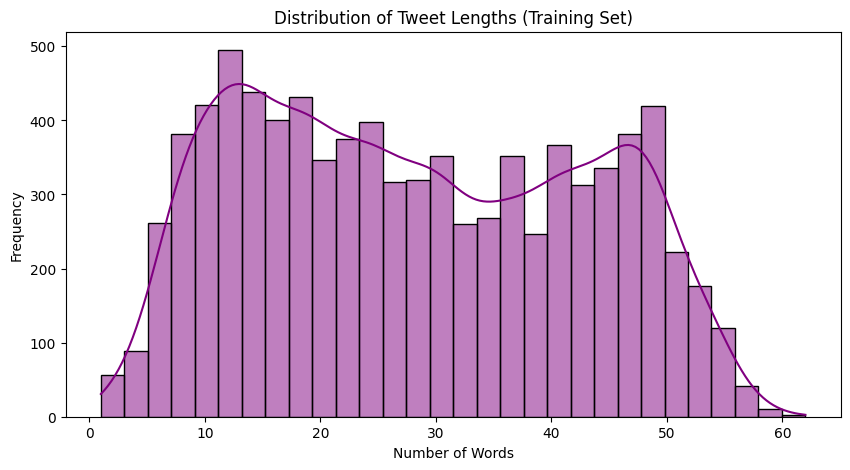

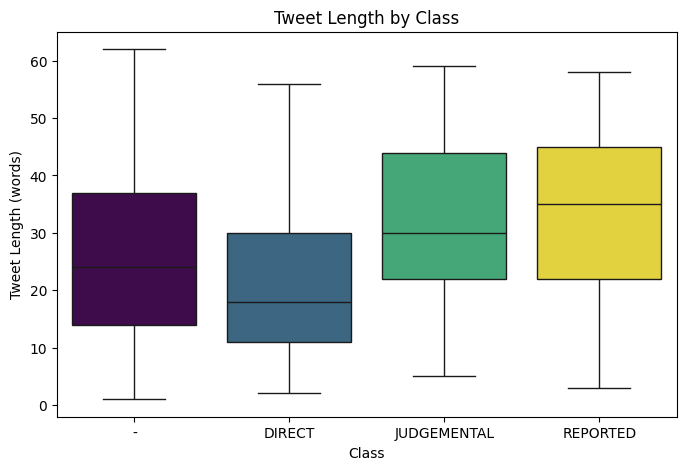

In [ ]:
label_map = {0: "NOT SEXIST", 1: "DIRECT", 2: "JUDGEMENTAL", 3: "REPORTED"}

# Count the labels.
label_counts = [train.label[train.label == i].count() for i in label_map.keys()]

majority = np.argmax(label_counts) # Get the majority class.

# Perform random upsampling until all the classes have an equal amount of entries.
for i in label_map:
  if i != majority:
    for _ in range(label_counts[majority] - label_counts[i]):
      train = pd.concat([pd.DataFrame(train[train.label == i].sample(1), \
                          columns=train.columns), train], ignore_index=True)

# Shuffle the new dataset to avoid big conecutive blocks of same label entries.
train = train.sample(frac=1).reset_index(drop=True)

print("AUGMENTATION DONE!")

# Plot the augmented dataset distributions.
plot_dists(train, test, "(After Augmentation)")

## Task 3: Text Encoding

### Build the vocabulary

In [ ]:
vectorizer = layers.TextVectorization()
vectorizer.adapt(train["text"])

In [ ]:
# Create a TensorFlow Dataset for training data
# Each batch contains 64 examples for efficient training
train_ds = tf.data.Dataset.from_tensor_slices((train["text"], train["label"])) \
    .map(lambda x, y: (vectorizer(x), y)) \
    .padded_batch(32) \
    .prefetch(tf.data.AUTOTUNE)

# Create a TensorFlow Dataset for validation data
valid_ds = tf.data.Dataset.from_tensor_slices((val["text"], val["label"])) \
    .map(lambda x, y: (vectorizer(x), y)) \
    .padded_batch(32) \
    .prefetch(tf.data.AUTOTUNE)
# Create a TensorFlow Dataset for test data
test_ds = tf.data.Dataset.from_tensor_slices((test["text"], test["label"])) \
    .map(lambda x, y: (vectorizer(x), y)).padded_batch(len(test)).prefetch(tf.data.AUTOTUNE)


The vectorizer has its vocabulary frozen after adapt().

When we apply it to the val or test set,

any word not seen during training will automatically be replaced with the OOV token (default **UNK**, index 1).

We do not need to manually preprocess or map OOV tokens, TensorFlow will handle it internally.

### Use GloVe Embedding vectors

#### Convert GloVe format to Word2Vec format

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    glove_dst = "/content/drive/MyDrive/glove.twitter.27B.50d.txt"
else:
    glove_dst = "glove.twitter.27B.50d.txt"
glove_src = "glove.twitter.27B.50d.txt"

if os.path.exists(glove_dst):
    print("GloVe file already exists in Drive.")
else:
    print("Downloading GloVe file...")
    !wget http://nlp.stanford.edu/data/glove.twitter.27B.zip
    !unzip -q glove.twitter.27B.zip
    print("Copying GloVe file...")
    !cp "$glove_src" "$glove_dst"
    print("File copied successfully!")

glove_file = glove_dst

GloVe file already exists in Drive.


In [ ]:
# Load GloVe into Gensim
twitter_glove = KeyedVectors.load_word2vec_format(glove_file, binary=False, no_header=True)

print(f"Loaded Twitter GloVe with {len(twitter_glove.key_to_index):,} tokens")

Loaded Twitter GloVe with 1,193,514 tokens


#### Build TensorFlow embedding matrix

In [ ]:
vocab = vectorizer.get_vocabulary()
embedding_dim = twitter_glove.vector_size
embedding_matrix = np.zeros((len(vocab), embedding_dim))

### OOV handling

#### Random embedding initialization for OOV words

Then we will learn them by training

In [ ]:
# Construct the embedding matrix using GloVe vectors or random initialization
# For each word in the vocabulary:
# - If the word exists in the pre-trained GloVe embeddings, use its vector.
# - Otherwise, initialize its vector with random values drawn from a uniform distribution
count_0 = 0
count_1 = 0
for i, word in enumerate(vocab):
    if i == 0: # Handling zero mask
        continue
    if word in twitter_glove:
        embedding_matrix[i] = twitter_glove[word]
        count_0 += 1
    else:
        embedding_matrix[i] = np.random.uniform(low=-0.05, high=0.05, size=embedding_dim)  # Changed random init strategy
        count_1 += 1
print(count_0)
print(count_1)

8446
2123


## Task 4 & 5

In [ ]:
def get_callbacks(verbose):
    return [ReduceLROnPlateau(
      monitor='val_loss',
      factor=0.5,
      patience=3,
      min_lr=1e-6,
      verbose=verbose
  ), tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    restore_best_weights=True,
    verbose=verbose
    ), TqdmCallback(verbose=0)]

def build_model(stacked=False, lr=1e-3):
    model = models.Sequential([
        layers.Embedding(
            input_dim=len(vocab),
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            mask_zero=True,
            trainable=True,
            name='encoder-embedding'
        ),
        layers.Bidirectional(
            layers.LSTM(LSTM_UNITS,
                        return_sequences=stacked,
                        kernel_regularizer=regularizers.l2(L2_FACTOR),
                        activation='leaky_relu',
                        recurrent_activation='sigmoid'
                       )
        ),
        #layers.LayerNormalization(),
        layers.Dropout(DROPOUT_RATE),
        layers.Bidirectional(
            layers.LSTM(LSTM_UNITS,
                        return_sequences=False,
                        kernel_regularizer=regularizers.l2(L2_FACTOR),
                        activation='leaky_relu',
                        recurrent_activation='sigmoid'
                        )
                       ) if stacked else layers.Identity(),
        #layers.LayerNormalization() if stacked else layers.Identity(),
        layers.Dropout(DROPOUT_RATE) if stacked else layers.Identity(),
        layers.Dense(
            64,
            activation = "leaky_relu",
            kernel_regularizer=regularizers.l2(L2_FACTOR)
        ),
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(4, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipvalue=1.0),
        metrics=['accuracy']
    )
    return model

def predict_batch(model, x):
    return model(x, training=False)

def evaluate_model(model, valid_ds, class_names=['NOT SEXIST', 'DIRECT', 'JUDGEMENTAL', 'REPORTED']):
    """
    Compute macro F1, precision, recall, and display classification report
    and confusion matrix on the validation set.
    """
    y_true = []
    y_pred_probs = []

    # Iterate over the validation dataset
    for x_batch, y_batch in valid_ds:
        # Get model predictions (probabilities) using the tf.function
        preds = predict_batch(model, x_batch)

        # Store true labels (ground truth)
        y_true.extend(y_batch.numpy())
        # Store predicted probabilities
        y_pred_probs.extend(preds.numpy())

    # Get the predicted class index (the one with the highest probability)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 1. Print the detailed Classification Report
    # This shows precision, recall, f1-score for each class
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print("---------------------------------")

    # 2. Compute and display the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    print("\nPlotting Confusion Matrix...")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Pred {name}' for name in class_names],
                yticklabels=[f'True {name}' for name in class_names])
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

    # 3. Calculate macro-averaged metrics
    # 'macro' calculates metrics for each label, and finds their unweighted mean.
    # This is crucial for imbalanced datasets.
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)

    return f1, prec, rec


Training baseline model with seed 42...


  0%|                                                 | 0/30 [00:00<?, ?epoch/s]2025-12-22 18:14:54.365999: I external/local_xla/xla/service/service.cc:163] XLA service 0x7966d400a400 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
2025-12-22 18:14:54.366020: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): AMD Radeon RX 7800 XT, AMDGPU ISA version: gfx1101
2025-12-22 18:14:54.410225: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-22 18:14:54.855745: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-22 18:14:54.855763: I external/local_xla/xla/service/gpu/a

Restoring model weights from the end of the best epoch: 30.


100%|█| 30/30 [01:20<00:00,  2.68s/epoch, accuracy=0.623, loss=1.02, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.71      0.53      0.61       185
      DIRECT       0.40      0.49      0.44        70
 JUDGEMENTAL       0.14      0.25      0.18        24
    REPORTED       0.15      0.21      0.17        33

    accuracy                           0.46       312
   macro avg       0.35      0.37      0.35       312
weighted avg       0.54      0.46      0.49       312

---------------------------------

Plotting Confusion Matrix...


2025-12-22 18:16:14.974246: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


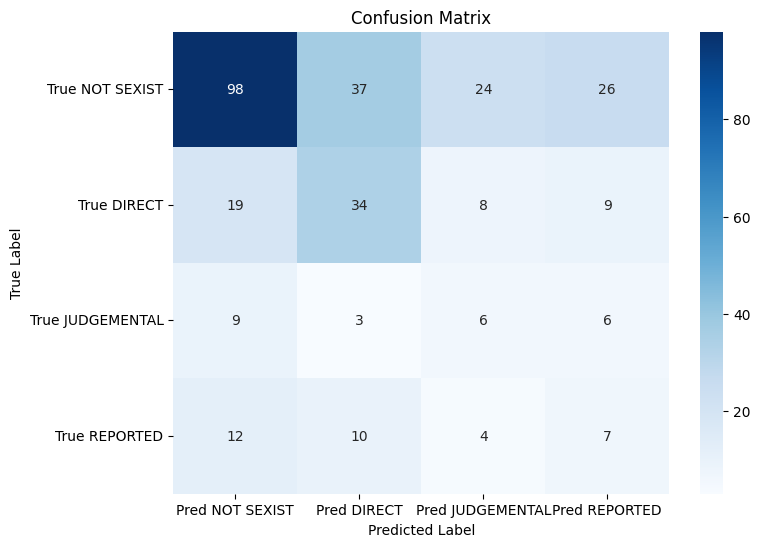


Training stacked model with seed 42...


 27%|▎| 8/30 [01:25<01:38,  4.47s/epoch, accuracy=0.264, loss=1.53, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

100%|█| 30/30 [01:54<00:00,  1.16s/epoch, accuracy=0.581, loss=1.08, val_accurac

Restoring model weights from the end of the best epoch: 30.


100%|█| 30/30 [01:54<00:00,  3.83s/epoch, accuracy=0.581, loss=1.08, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.82      0.51      0.63       185
      DIRECT       0.50      0.50      0.50        70
 JUDGEMENTAL       0.13      0.67      0.22        24
    REPORTED       0.29      0.06      0.10        33

    accuracy                           0.47       312
   macro avg       0.44      0.43      0.36       312
weighted avg       0.64      0.47      0.51       312

---------------------------------

Plotting Confusion Matrix...


2025-12-22 18:18:11.544717: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


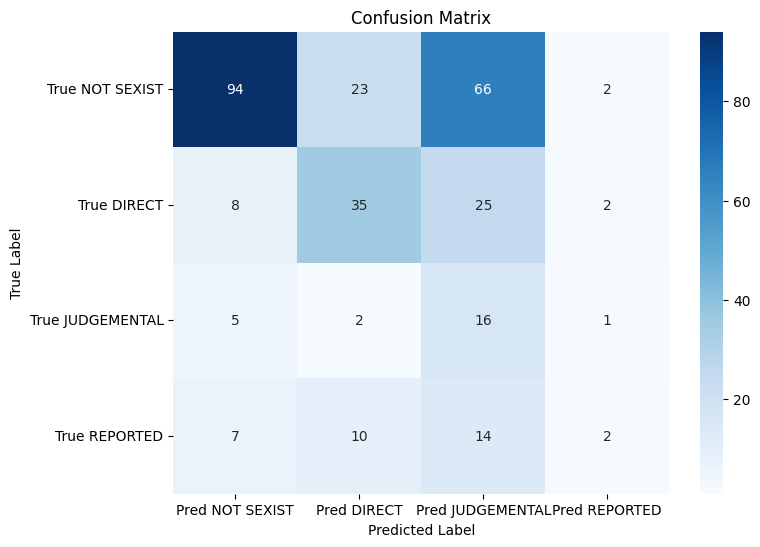


Training baseline model with seed 123...


 27%|▎| 8/30 [01:00<01:06,  3.04s/epoch, accuracy=0.292, loss=1.52, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

 60%|▌| 18/30 [01:09<00:07,  1.55epoch/s, accuracy=0.396, loss=1.39, val_accurac


Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 70%|▋| 21/30 [01:11<00:05,  1.53epoch/s, accuracy=0.409, loss=1.36, val_accurac

Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 16.


 70%|▋| 21/30 [01:11<00:30,  3.39s/epoch, accuracy=0.409, loss=1.36, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.76      0.56      0.64       185
      DIRECT       0.47      0.66      0.55        70
 JUDGEMENTAL       0.17      0.54      0.26        24
    REPORTED       0.33      0.03      0.06        33

    accuracy                           0.52       312
   macro avg       0.43      0.45      0.38       312
weighted avg       0.61      0.52      0.53       312

---------------------------------

Plotting Confusion Matrix...


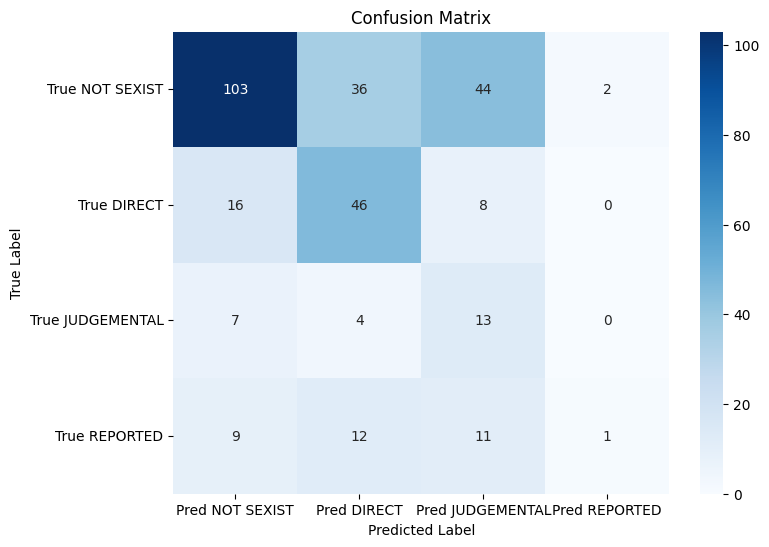


Training stacked model with seed 123...


 27%|▎| 8/30 [01:22<01:36,  4.37s/epoch, accuracy=0.289, loss=1.53, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

 90%|▉| 27/30 [01:47<00:03,  1.03s/epoch, accuracy=0.464, loss=1.19, val_accurac


Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


100%|█| 30/30 [01:51<00:00,  1.17s/epoch, accuracy=0.508, loss=1.17, val_accurac

Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 25.


100%|█| 30/30 [01:51<00:00,  3.72s/epoch, accuracy=0.508, loss=1.17, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.81      0.31      0.45       185
      DIRECT       0.29      0.93      0.44        70
 JUDGEMENTAL       0.00      0.00      0.00        24
    REPORTED       0.13      0.06      0.08        33

    accuracy                           0.40       312
   macro avg       0.31      0.33      0.24       312
weighted avg       0.56      0.40      0.38       312

---------------------------------

Plotting Confusion Matrix...


2025-12-22 18:21:17.464175: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


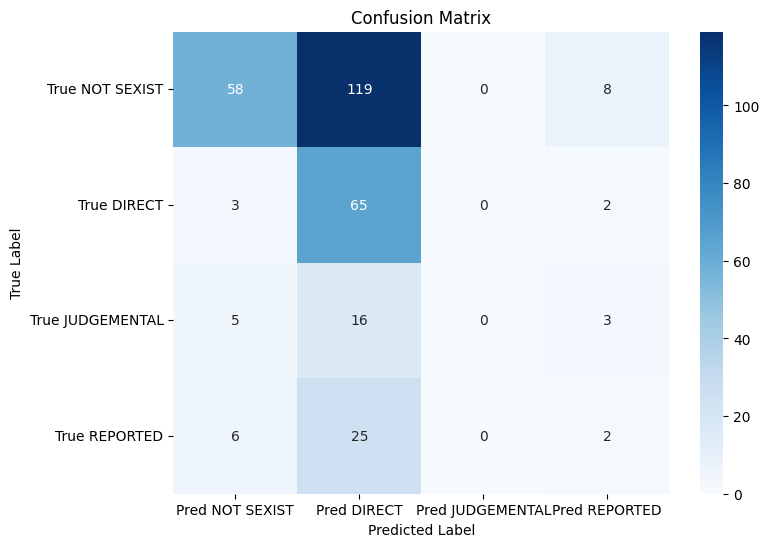


Training baseline model with seed 999...


 27%|▎| 8/30 [00:56<01:03,  2.88s/epoch, accuracy=0.298, loss=1.49, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

 67%|▋| 20/30 [01:06<00:06,  1.54epoch/s, accuracy=0.419, loss=1.35, val_accurac


Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 93%|▉| 28/30 [01:11<00:01,  1.72epoch/s, accuracy=0.498, loss=1.22, val_accurac


Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


100%|█| 30/30 [01:12<00:00,  1.60epoch/s, accuracy=0.542, loss=1.18, val_accurac

Restoring model weights from the end of the best epoch: 30.


100%|█| 30/30 [01:12<00:00,  2.41s/epoch, accuracy=0.542, loss=1.18, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.75      0.56      0.64       185
      DIRECT       0.45      0.49      0.47        70
 JUDGEMENTAL       0.12      0.42      0.19        24
    REPORTED       0.24      0.12      0.16        33

    accuracy                           0.49       312
   macro avg       0.39      0.40      0.37       312
weighted avg       0.58      0.49      0.52       312

---------------------------------

Plotting Confusion Matrix...


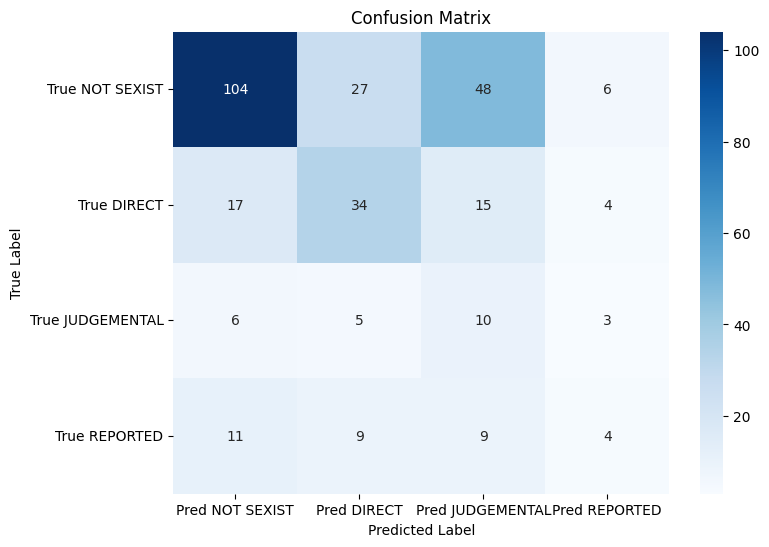


Training stacked model with seed 999...


 27%|▎| 8/30 [01:18<01:32,  4.21s/epoch, accuracy=0.243, loss=1.52, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

 57%|▌| 17/30 [01:32<00:18,  1.40s/epoch, accuracy=0.309, loss=1.44, val_accurac


Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


 70%|▋| 21/30 [01:36<00:10,  1.21s/epoch, accuracy=0.348, loss=1.4, val_accuracy


Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


...


Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


100%|█| 30/30 [01:46<00:00,  1.19s/epoch, accuracy=0.398, loss=1.32, val_accurac

Restoring model weights from the end of the best epoch: 26.


100%|█| 30/30 [01:46<00:00,  3.56s/epoch, accuracy=0.398, loss=1.32, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.64      0.04      0.07       185
      DIRECT       0.34      0.81      0.47        70
 JUDGEMENTAL       0.11      0.17      0.14        24
    REPORTED       0.11      0.33      0.17        33

    accuracy                           0.25       312
   macro avg       0.30      0.34      0.21       312
weighted avg       0.47      0.25      0.18       312

---------------------------------

Plotting Confusion Matrix...


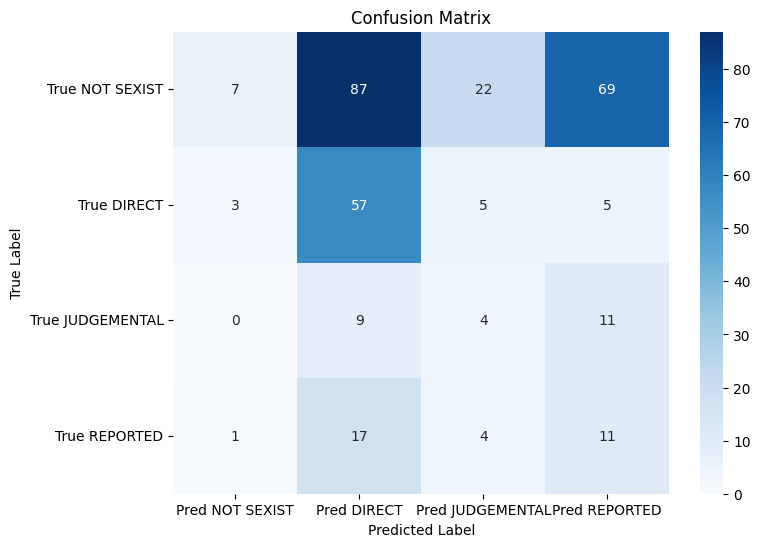


Retraining best base model with seed 123...


 27%|▎| 8/30 [00:56<01:00,  2.76s/epoch, accuracy=0.292, loss=1.52, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

 70%|▋| 21/30 [01:06<00:28,  3.18s/epoch, accuracy=0.409, loss=1.36, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.76      0.56      0.64       185
      DIRECT       0.47      0.66      0.55        70
 JUDGEMENTAL       0.17      0.54      0.26        24
    REPORTED       0.33      0.03      0.06        33

    accuracy                           0.52       312
   macro avg       0.43      0.45      0.38       312
weighted avg       0.61      0.52      0.53       312

---------------------------------

Plotting Confusion Matrix...


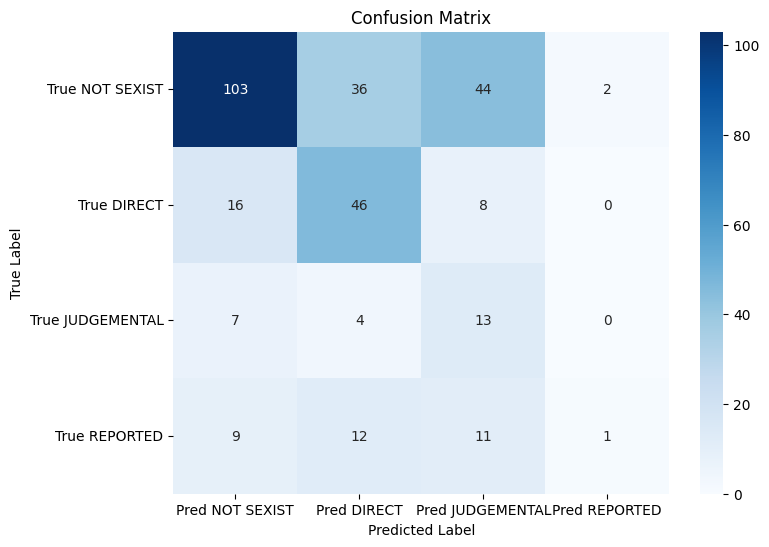

Best model saved as 'best_base_model.keras'

Retraining best stacked model with seed 42...


 27%|▎| 8/30 [01:12<01:22,  3.74s/epoch, accuracy=0.264, loss=1.53, val_accuracy/usr/local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.

100%|█| 30/30 [01:41<00:00,  3.37s/epoch, accuracy=0.518, loss=1.18, val_accurac



--- Classification Report ---
              precision    recall  f1-score   support

  NOT SEXIST       0.84      0.43      0.57       185
      DIRECT       0.45      0.56      0.50        70
 JUDGEMENTAL       0.12      0.62      0.20        24
    REPORTED       0.38      0.09      0.15        33

    accuracy                           0.44       312
   macro avg       0.45      0.43      0.35       312
weighted avg       0.65      0.44      0.48       312

---------------------------------

Plotting Confusion Matrix...


2025-12-22 18:27:11.166935: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


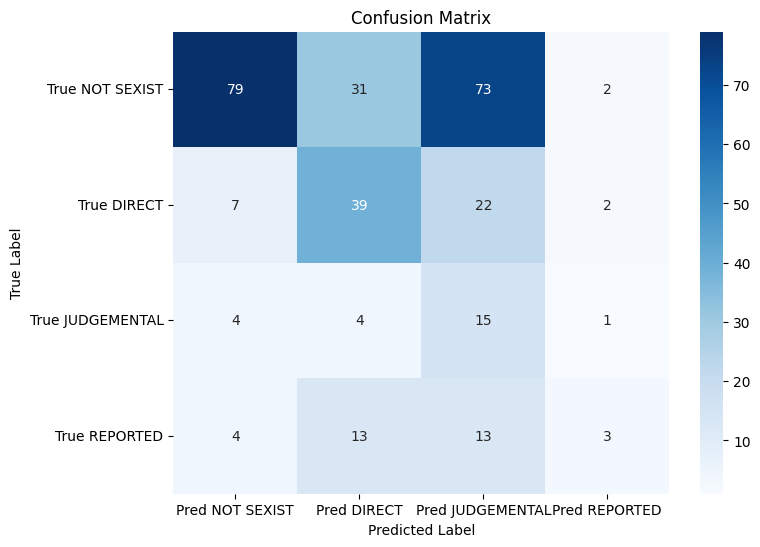

Best model saved as 'best_stacked_model.keras'


In [ ]:
# Hyperparameters
LSTM_UNITS = 25 # Per LSTM layer.
DROPOUT_RATE = 0.7
LR = 1e-3
EPOCHS = 30
SEEDS = [42, 123, 999]
L2_FACTOR = 1e-3
classes = [0, 1, 2, 3]

f1_scores_base, precisions_base, recalls_base = [], [], []
f1_scores_stacked, precisions_stacked, recalls_stacked = [], [], []

for seed, stacked in list(product(SEEDS, [False, True])):
    print(f"\nTraining {"stacked" if stacked else "baseline"} model with seed {seed}...")
    tf.keras.utils.set_random_seed(seed)
    model = build_model(stacked, LR)

    model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS,
        steps_per_epoch=32,
        callbacks=get_callbacks(True),
        verbose=0
    )
    f1, prec, rec = evaluate_model(model, test_ds)
    del model
    if 'best_model' in locals(): del best_model
    K.clear_session()
    gc.collect()
    f1_scores_stacked.append(f1) if stacked else f1_scores_base.append(f1)
    precisions_stacked.append(prec) if stacked else precisions_base.append(prec)
    recalls_stacked.append(rec) if stacked else recalls_base.append(rec)

history_best = []
for stacked in [False, True]:
    best_seed = SEEDS[np.argmax(f1_scores_stacked if stacked else f1_scores_base)]
    print(f"\nRetraining best {"stacked" if stacked else "base"} model with seed {best_seed}...")
    tf.keras.utils.set_random_seed(best_seed)
    best_model = build_model(stacked, LR)
    history = best_model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS,
        steps_per_epoch=32,
        callbacks=get_callbacks(False),
        verbose=0

    )
    history_best.append(history.history)
    evaluation = evaluate_model(best_model, test_ds)
    best_model.save(f"best_{"stacked" if stacked else "base"}_model.keras")
    del best_model
    del history
    if 'best_model' in locals(): del best_model
    K.clear_session()
    gc.collect()
    print(f"Best model saved as 'best_{"stacked" if stacked else "base"}_model.keras'")

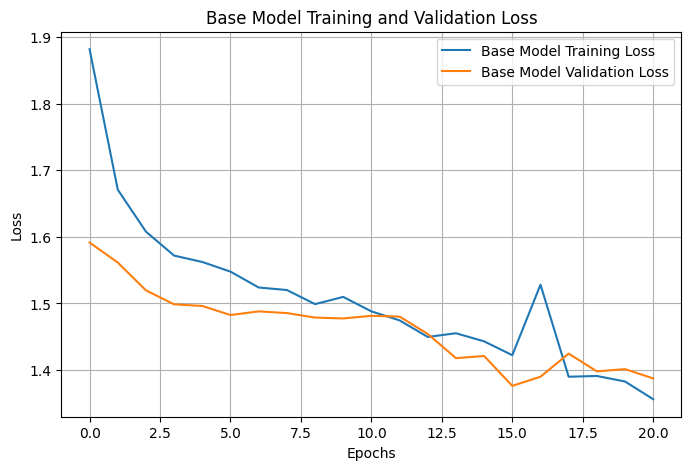

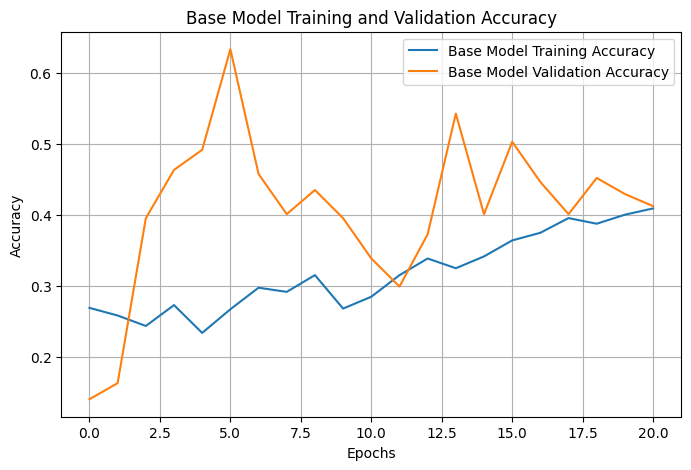

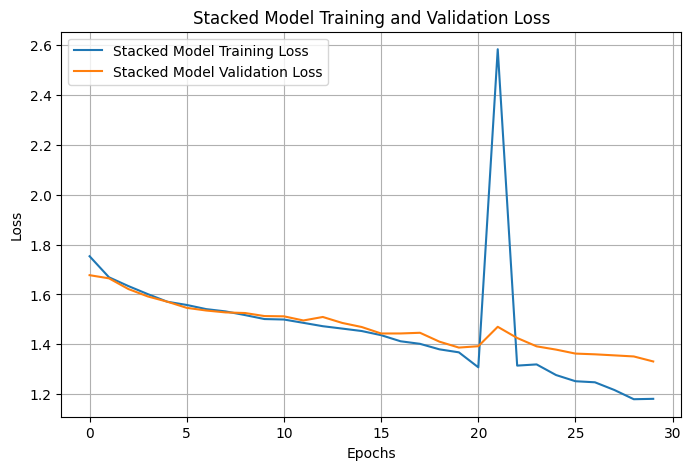

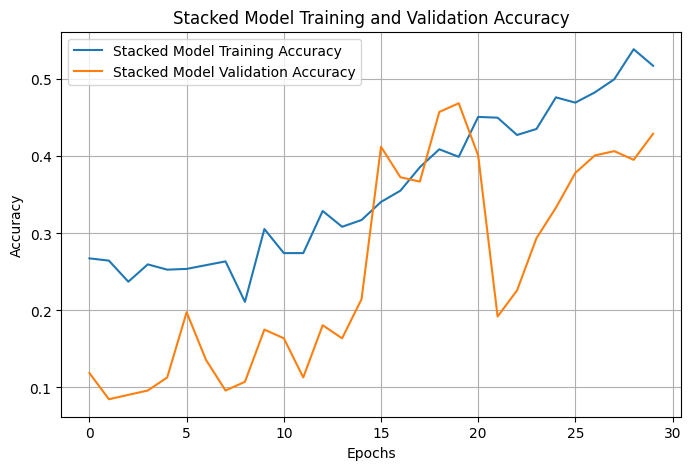

In [ ]:
#Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_best[0]['loss'], label='Base Model Training Loss')
plt.plot(history_best[0]['val_loss'], label='Base Model Validation Loss')
plt.title('Base Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Plot accuracy as well
plt.figure(figsize=(8, 5))
plt.plot(history_best[0]['accuracy'], label='Base Model Training Accuracy')
plt.plot(history_best[0]['val_accuracy'], label='Base Model Validation Accuracy')
plt.title('Base Model Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()



# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_best[1]['loss'], label='Stacked Model Training Loss')
plt.plot(history_best[1]['val_loss'], label='Stacked Model Validation Loss')
plt.title('Stacked Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Plot accuracy as well
plt.figure(figsize=(8, 5))
plt.plot(history_best[1]['accuracy'], label='Stacked Model Training Accuracy')
plt.plot(history_best[1]['val_accuracy'], label='Stacked Model Validation Accuracy')
plt.title('Stacked Model Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()




## Task 6: Transformers

In [ ]:
torch.cuda.is_available()

True

In [ ]:
# Convert train/valid/test to HuggingFace Dataset
train_texts = train["text"].values
train_labels = train["label"].values

valid_texts = val["text"].values
valid_labels = val["label"].values

test_texts = test["text"].values
test_labels = test["label"].values

train_ds = Dataset.from_dict({
    "text": train_texts.tolist(),
    "labels": train_labels.tolist()
})

valid_ds = Dataset.from_dict({
    "text": valid_texts.tolist(),
    "labels": valid_labels.tolist()
})

test_ds = Dataset.from_dict({
    "text": test_texts.tolist(),
    "labels": test_labels.tolist()
})

In [ ]:
def show_learning_curves(trainer_history, seed):
    epochs_loss = []
    train_loss = []
    epochs_eval = []
    val_loss = []
    val_f1 = []

    for entry in trainer_history:
        if 'loss' in entry:
            train_loss.append(entry['loss'])
            epochs_loss.append(entry['epoch'])
        if 'eval_loss' in entry:
            val_loss.append(entry['eval_loss'])
            val_f1.append(entry['eval_f1'])
            epochs_eval.append(entry['epoch'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss Plot
    ax1.plot(epochs_loss, train_loss, label='Training Loss', marker='o')
    ax1.plot(epochs_eval, val_loss, label='Validation Loss', marker='x')
    ax1.set_title(f'Loss Curves - Seed {seed}')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # F1 Plot
    ax2.plot(epochs_eval, val_f1, label='Validation F1', color='green', marker='s')
    ax2.set_title(f'F1 Score Curve - Seed {seed}')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('F1 Score')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
def report_detailed_metrics(trainer, dataset, seed):
    # Get predictions
    output = trainer.predict(dataset)
    y_true = output.label_ids
    y_pred = np.argmax(output.predictions, axis=-1)

    target_names = ["Non SEXIST", "DIRECT", "JUDGEMENTAL", "REPORTED"]

    # Classification Report
    print(f"\n--- Classification Report (Seed {seed}) ---")
    print(classification_report(y_true, y_pred, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"Confusion Matrix (Seed {seed})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/8604 [00:00<?, ? examples/s]

Map:   0%|          | 0/177 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]


RUNNING WITH SEED: 42


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.182900,1.028831,0.621469,0.490014,0.534057,0.519048
2,1.037500,1.127079,0.610169,0.477468,0.463374,0.541071
3,0.993300,0.956748,0.644068,0.494160,0.475580,0.546726
4,0.972100,0.989172,0.604520,0.428994,0.437877,0.466964
5,0.959800,0.974625,0.621469,0.451976,0.447473,0.494643


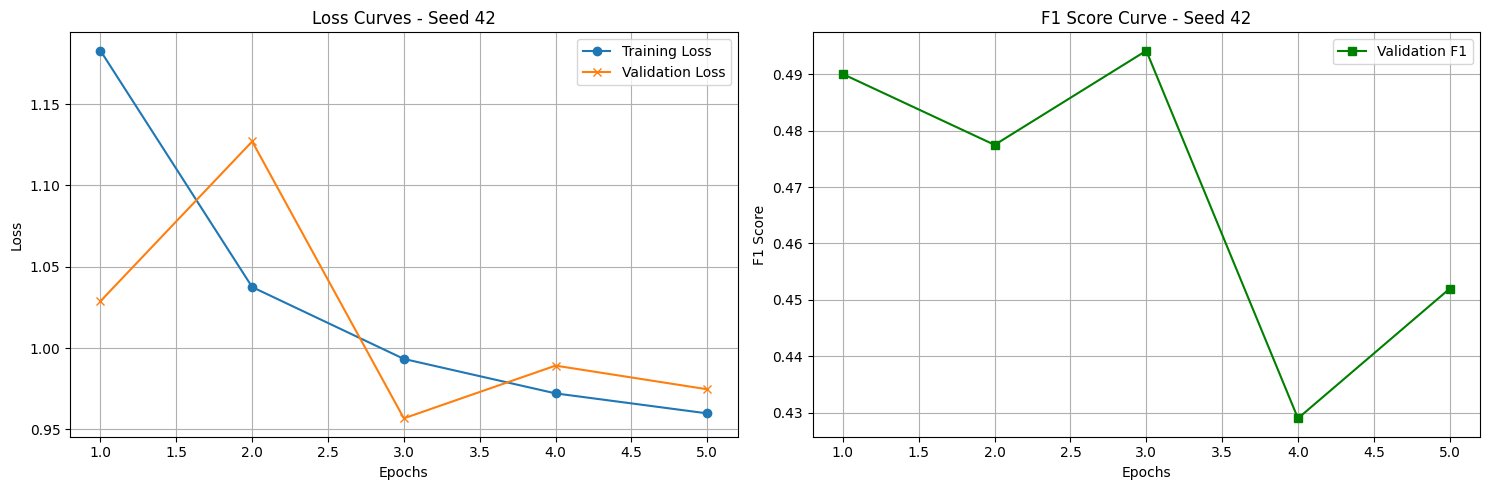

Retrieving best validation metrics for Seed 42...


Best Validation F1 (Macro): 0.4941601988996985

Evaluating Seed 42 on Test Set...

--- Classification Report (Seed 42) ---
              precision    recall  f1-score   support

  Non SEXIST       0.90      0.72      0.80       185
      DIRECT       0.56      0.60      0.58        70
 JUDGEMENTAL       0.15      0.25      0.19        24
    REPORTED       0.27      0.39      0.32        33

    accuracy                           0.62       312
   macro avg       0.47      0.49      0.47       312
weighted avg       0.70      0.62      0.65       312



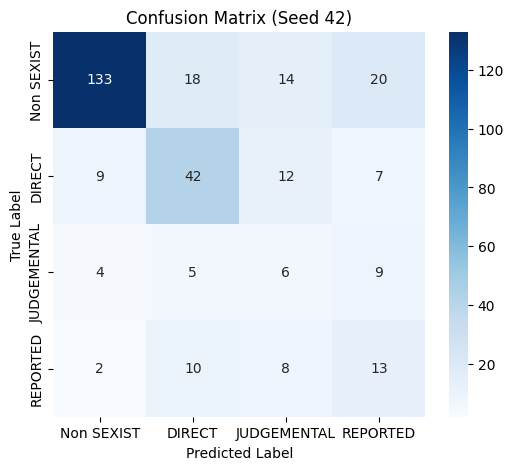

early stopping required metric_for_best_model, but did not find eval_f1 so early stopping is disabled


Test F1 (Macro): 0.4706705785895231

RUNNING WITH SEED: 123


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.180200,1.024721,0.615819,0.469219,0.472747,0.516964
2,1.031300,0.993727,0.632768,0.478529,0.461819,0.535714
3,0.988000,0.962184,0.638418,0.486110,0.470886,0.536905
4,0.966300,0.974066,0.632768,0.482856,0.468646,0.534821
5,0.961800,0.988840,0.610169,0.450084,0.444928,0.498214


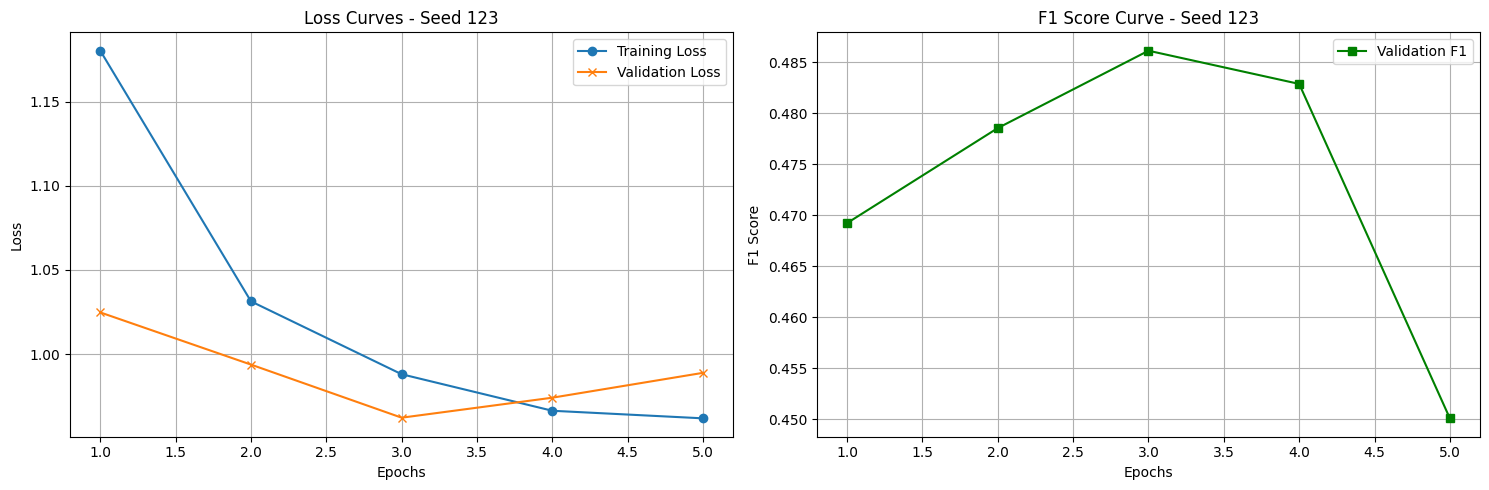

Retrieving best validation metrics for Seed 123...


Best Validation F1 (Macro): 0.4861095275478642

Evaluating Seed 123 on Test Set...

--- Classification Report (Seed 123) ---
              precision    recall  f1-score   support

  Non SEXIST       0.91      0.72      0.80       185
      DIRECT       0.55      0.60      0.58        70
 JUDGEMENTAL       0.18      0.29      0.22        24
    REPORTED       0.29      0.42      0.34        33

    accuracy                           0.63       312
   macro avg       0.48      0.51      0.49       312
weighted avg       0.70      0.63      0.66       312



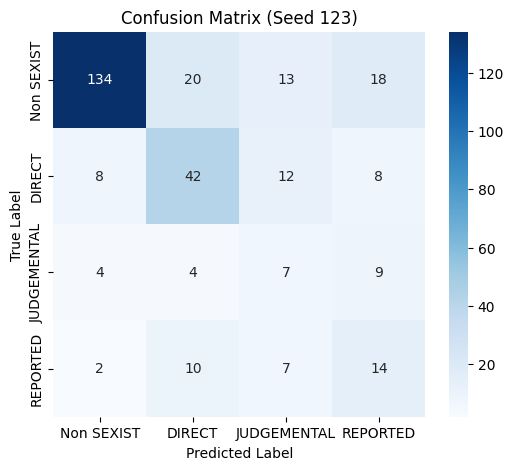

early stopping required metric_for_best_model, but did not find eval_f1 so early stopping is disabled


Test F1 (Macro): 0.4859582268536495

RUNNING WITH SEED: 2024


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-hate and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([4]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.178300,1.161168,0.593220,0.443278,0.449091,0.492857
2,1.030200,0.987282,0.621469,0.471080,0.460326,0.525893
3,0.988700,0.977505,0.615819,0.455231,0.447492,0.509226
4,0.966900,0.952484,0.621469,0.451812,0.444747,0.495536


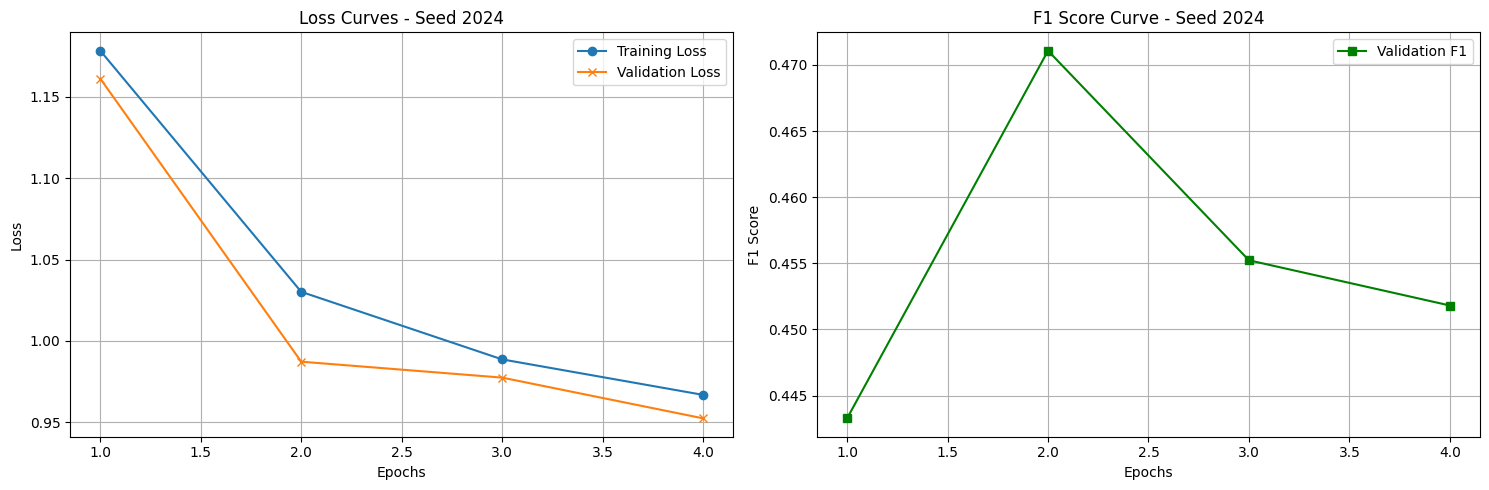

Retrieving best validation metrics for Seed 2024...


Best Validation F1 (Macro): 0.4710795371967672

Evaluating Seed 2024 on Test Set...

--- Classification Report (Seed 2024) ---
              precision    recall  f1-score   support

  Non SEXIST       0.90      0.71      0.80       185
      DIRECT       0.56      0.61      0.59        70
 JUDGEMENTAL       0.14      0.25      0.18        24
    REPORTED       0.28      0.39      0.33        33

    accuracy                           0.62       312
   macro avg       0.47      0.49      0.47       312
weighted avg       0.70      0.62      0.65       312



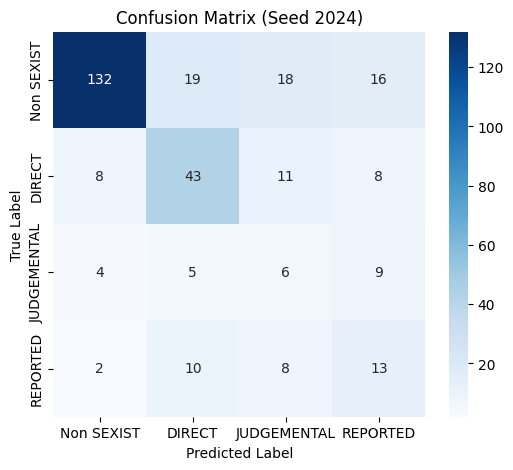

early stopping required metric_for_best_model, but did not find eval_f1 so early stopping is disabled


Test F1 (Macro): 0.4727088742097531

########################################
INDIVIDUAL SEED RESULTS
########################################
 Seed  Vali Accuracy  Valid Precision  Valid Recall  Valid F1  Test Accuracy  Test Precision  Test Recall  Test F1
   42       0.644068         0.475580      0.546726   0.49416       0.621795        0.468489     0.490715 0.470671
  123       0.638418         0.470886      0.536905   0.48611       0.631410        0.480810     0.510058 0.485958
 2024       0.621469         0.460326      0.525893   0.47108       0.621795        0.471174     0.492935 0.472709

########################################
ROBUST ESTIMATION (SUMMARY)
########################################
                     mean       std
Vali Accuracy    0.634652  0.011761
Valid Precision  0.468931  0.007813
Valid Recall     0.536508  0.010422
Valid F1         0.483783  0.011715
Test Accuracy    0.625000  0.005551
Test Precision   0.473491  0.006479
Test Recall      0.497903  0.01058

In [ ]:
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, set_seed
import evaluate
import numpy as np
import pandas as pd

seeds = [42, 123, 2024]
results_list = []

# 1. Load the Tokenizer and Model
model_card = "cardiffnlp/twitter-roberta-base-hate"
tokenizer = AutoTokenizer.from_pretrained(model_card)

model = AutoModelForSequenceClassification.from_pretrained(
    model_card,
    num_labels=4,
    ignore_mismatched_sizes=True
)

# 2. Preprocess the Dataset
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

# Map tokenization to the Dataset objects
train_dataset = train_ds.map(tokenize_function, batched=True)
val_dataset = valid_ds.map(tokenize_function, batched=True)
test_dataset = test_ds.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3. Define Metrics
acc_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = acc_metric.compute(predictions=predictions, references=labels)
    # Compute all macro metrics
    f1 = f1_metric.compute(predictions=predictions, references=labels, average='macro')
    precision = precision_metric.compute(predictions=predictions, references=labels, average='macro')
    recall = recall_metric.compute(predictions=predictions, references=labels, average='macro')

    return {**acc, **f1, **precision, **recall}

# Update the Training Loop with Freezing and Label Smoothing
for seed in seeds:
    print(f"\n" + "="*60)
    print(f"RUNNING WITH SEED: {seed}")
    print("="*60)

    set_seed(seed)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_card,
        num_labels=4,
        ignore_mismatched_sizes=True
    )

    # FREEZE RoBERTa ENCODER
    # We freeze all layers of the base model except for the classification head
    for name, param in model.roberta.named_parameters():
        param.requires_grad = False

    training_args = TrainingArguments(
        output_dir=f"./transformer_seed_{seed}",
        learning_rate=2e-5,
        # lr_scheduler_type="cosine",      # Cosine decay for smooth convergence
        # warmup_ratio=0.1,                # Warmup for stability
        weight_decay=0.01,                 # L2 Regularization
        # label_smoothing_factor=0.1,      # Label Smoothing for better generalization
        num_train_epochs=5,                # Managed by Early Stopping
        # gradient_accumulation_steps=2,   # Effectively doubles batch size
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",      # Optimize for Macro F1
        seed = seed,
        report_to="none"                 # Give up dear wandb :)
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # Learning Curves, Metrics, and Confusion Matrix
    show_learning_curves(trainer.state.log_history, seed)

    # Retrieve Best Validation Metrics (from the best checkpoint loaded at the end)
    print(f"Retrieving best validation metrics for Seed {seed}...")

    val_metrics = trainer.evaluate(val_dataset)
    print(f"Best Validation F1 (Macro): {val_metrics["eval_f1"]}")

    # Detailed Performance on Test Set
    print(f"\nEvaluating Seed {seed} on Test Set...")
    report_detailed_metrics(trainer, test_dataset, seed)

    # Evaluate on the Test Set for this specific seed
    test_metrics = trainer.evaluate(test_dataset, metric_key_prefix="test")
    print(f"Test F1 (Macro): {test_metrics["test_f1"]}")

    # Store both sets of results
    results_list.append({
        "Seed": seed,
        "Vali Accuracy": val_metrics["eval_accuracy"],
        "Valid Precision": val_metrics["eval_precision"],
        "Valid Recall": val_metrics["eval_recall"],
        "Valid F1": val_metrics["eval_f1"],
        "Test Accuracy": test_metrics["test_accuracy"],
        "Test Precision": test_metrics["test_precision"],
        "Test Recall": test_metrics["test_recall"],
        "Test F1": test_metrics["test_f1"]
    })

# Reporting Results

# 1. Report for each seed separately first
print("\n" + "#"*40)
print("INDIVIDUAL SEED RESULTS")
print("#"*40)
results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

# 2. Report average and standard deviation
print("\n" + "#"*40)
print("ROBUST ESTIMATION (SUMMARY)")
print("#"*40)

summary_stats = results_df.drop(columns='Seed').agg(['mean', 'std']).T
print(summary_stats)